# Classification of Pet's Faces

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

### Getting the Data

In this assignment, we will focus on relatively simple classification task - classification of pet's faces. This dataset consists of cut-out faces from [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Let's start by loading and visualizing the dataset.

In [ ]:
!wget https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz 
!tar xfz images.tar.gz
!rm images.tar.gz

In [ ]:
import os
import shutil

for filename in os.listdir('images'):
    prefix = filename.split('_')[0]
    target_dir = os.path.join('images', prefix)
    os.makedirs(target_dir, exist_ok=True)
    src = os.path.join('images', filename)
    dst = os.path.join(target_dir, filename)
    shutil.move(src, dst)

We will define generic function to display a series of images from a list:

In [28]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

Now let's traverse all class subdirectories and plot first few images of each class:

Sphynx


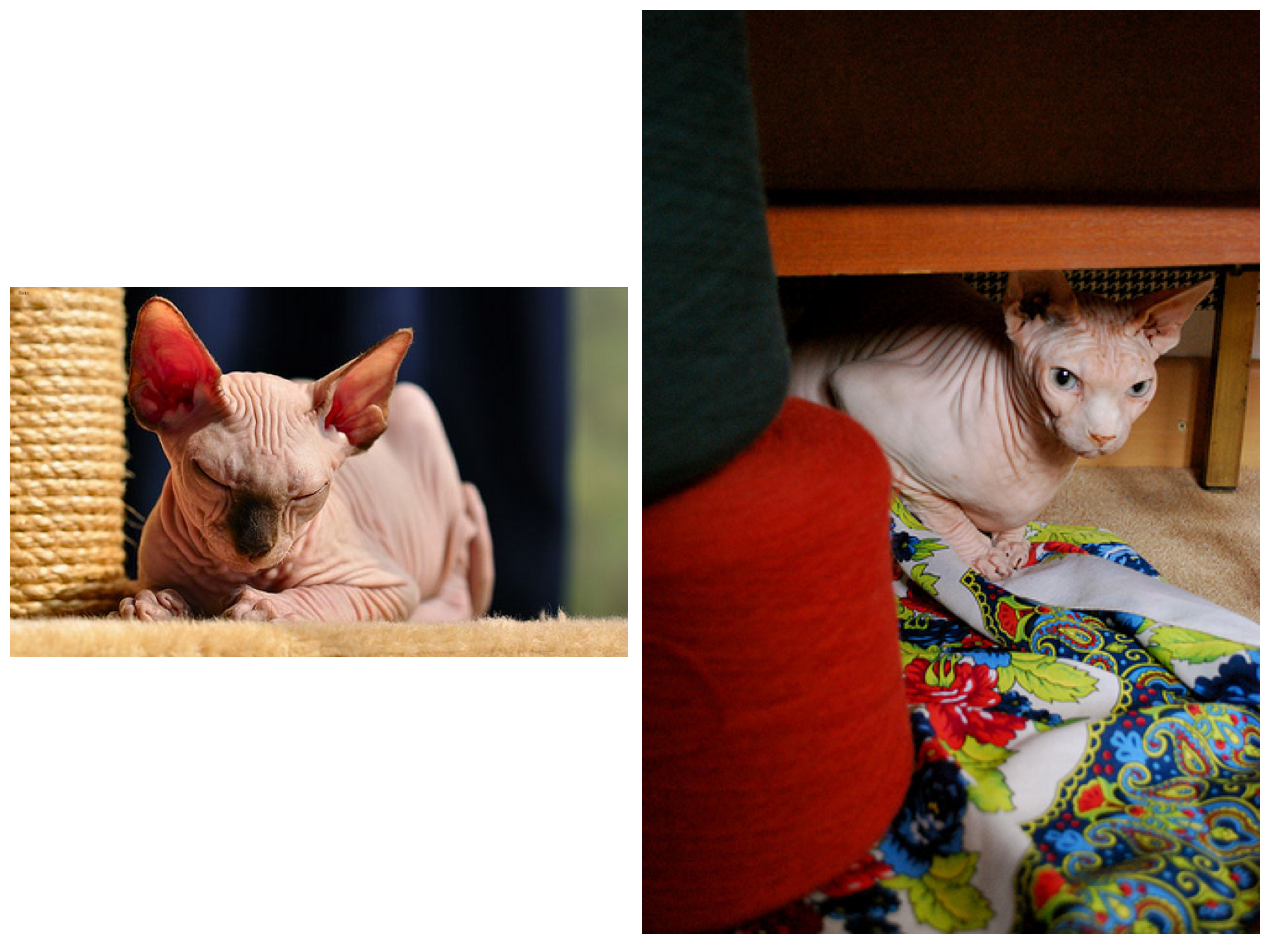

saint


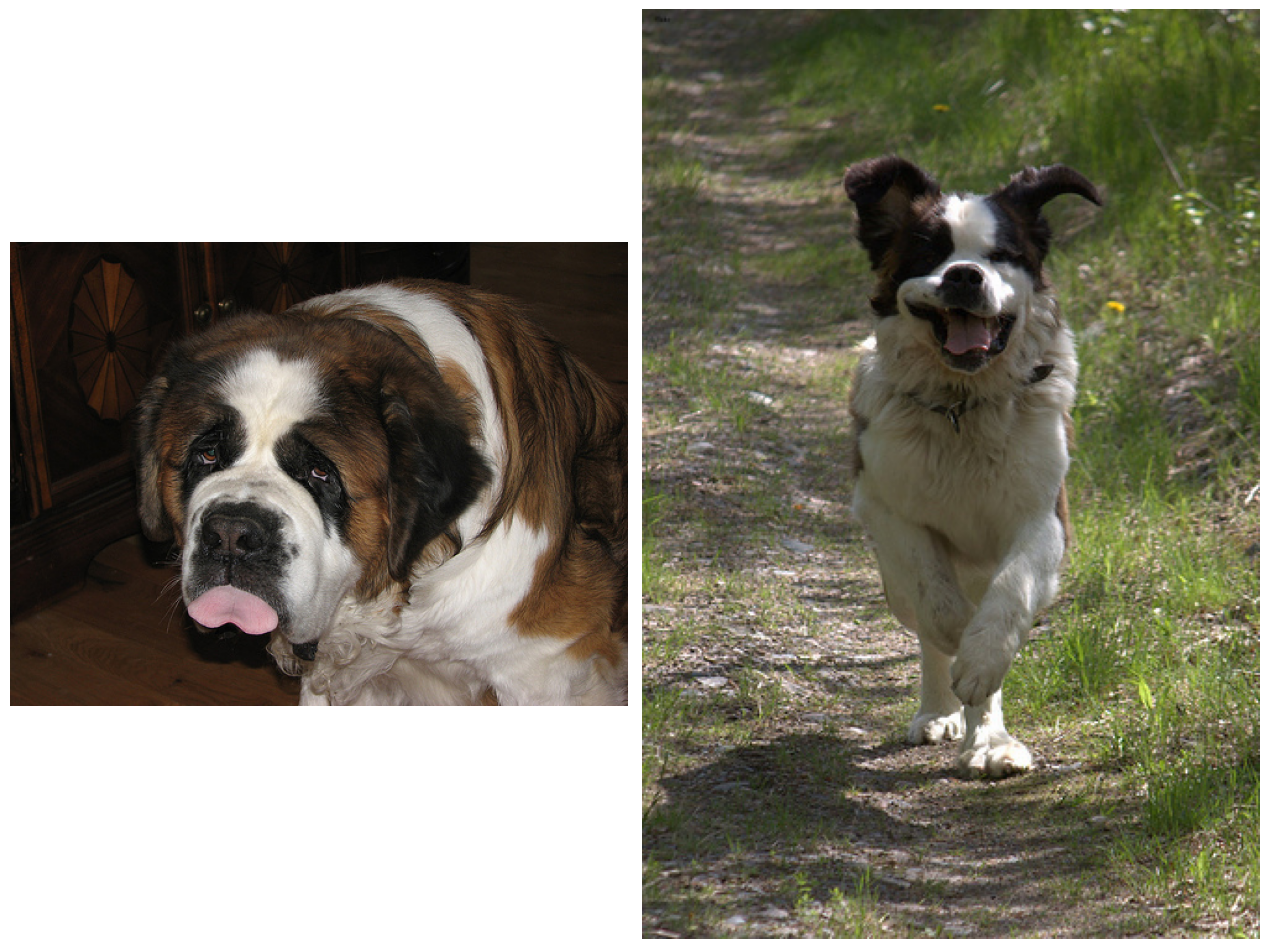

Birman


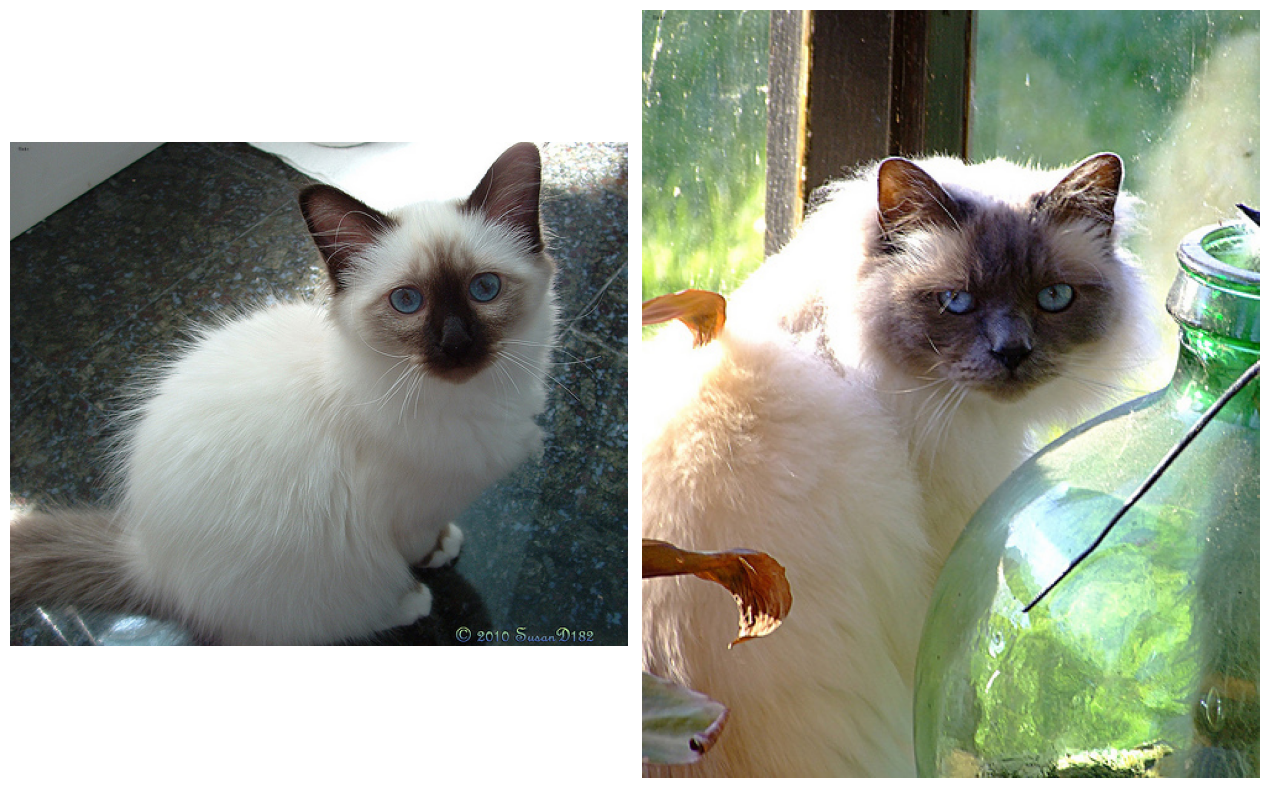

In [31]:
for cls in list(os.listdir('images'))[:3]:  # Only sample 3 classes
    print(cls)
    display_images([Image.open(os.path.join('images', cls, x)) 
                    for x in os.listdir(os.path.join('images', cls))[:2]])

Let's also define the number of classes in our dataset:

In [6]:
num_classes = len(os.listdir('images'))
num_classes

35

## Preparing dataset for Deep Learning

To start training our neural network, we need to convert all images to tensors, and also create tensors corresponding to labels (class numbers). Most neural network frameworks contain simple tools for dealing with images:
* In Tensorflow, use `tf.keras.preprocessing.image_dataset_from_directory`
* In PyTorch, use `torchvision.datasets.ImageFolder`

As you have seen from the pictures above, all of them are close to square image ratio, so we need to resize all images to square size. Also, we can organize images in minibatches.

In [7]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # commonly used for models pretrained on ImageNet
])

dataset = datasets.ImageFolder('images', transform=transform)

batch_size = 32
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Othe

Now we need to separate dataset into train and test portions:

In [8]:
from torch.utils.data import random_split, DataLoader

train_ratio = 0.8
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Now let's print the size of tensors in our dataset. If you have done everything correctly, the size of training elements should be
 * `(batch_size,image_size,image_size,3)` for Tensorflow, `batch_size,3,image_size,image_size` for PyTorch
 * `batch_size` for Labels
 
 Labels should contain numbers of classes.

In [9]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)   # Should be [batch_size, 3, 128, 128]
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


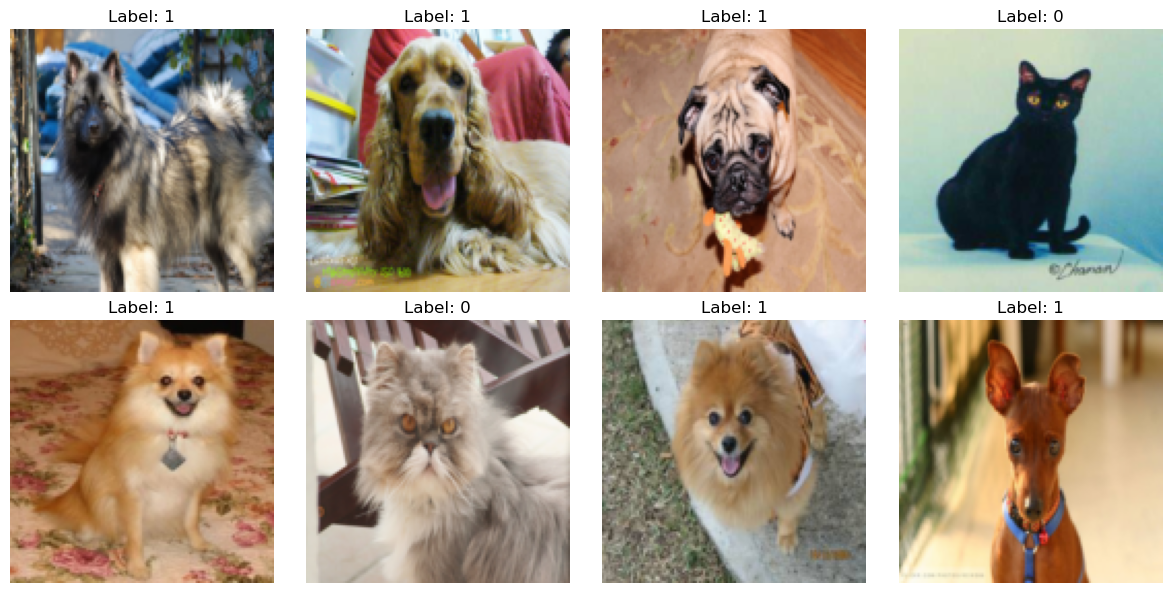

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and display images
def imshow(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = img.numpy().transpose((1, 2, 0))  # [C,H,W] -> [H,W,C]
    img = std * img + mean                  # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# Display a batch of images with their labels
images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 6))
for i in range(8):  # show first 8 images
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(f"Label: {labels[i].item()}")
plt.tight_layout()
plt.show()

## Define a neural network

For image classification, you should probably define a convolutional neural network with several layers. What to keep an eye for:
* Keep in mind the pyramid architecture, i.e. number of filters should increase as you go deeper
* Do not forget activation functions between layers (ReLU) and Max Pooling
* Final classifier can be with or without hidden layers, but the number of output neurons should be equal to number of classes.

An important thing is to get the activation function on the last layer + loss function right:
* In Tensorflow, you can use `softmax` as the activation, and `sparse_categorical_crossentropy` as loss. The difference between sparse categorical cross-entropy and non-sparse one is that the former expects output as the number of class, and not as one-hot vector.
* In PyTorch, you can have the final layer without activation function, and use `CrossEntropyLoss` loss function. This function applies softmax automatically. 

In [11]:
import torch.nn as nn

class PetFacesCNN(nn.Module):
    def __init__(self, num_classes):
        super(PetFacesCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)   # Input: 3x128x128, Output: 16x128x128
        self.pool = nn.MaxPool2d(2, 2)                            # Output: 16x64x64
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)  # Output: 32x64x64
        # After pooling: 32x32x32
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Train the Neural Network

Now we are ready to train the neural network. During training, please collect accuracy on train and test data on each epoch, and then plot the accuracy to see if there is overfitting.

> To speed up training, you need to use GPU if available. While TensorFlow/Keras will automatically use GPU, in PyTorch you need to move both the model and data to GPU during training using `.to()` method in order to take advantage of GPU acceleration. 


In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PetFacesCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = correct / total
    train_acc_history.append(train_acc)

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = correct / total
    test_acc_history.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/10], Train Acc: 0.0563, Test Acc: 0.0763
Epoch [2/10], Train Acc: 0.1021, Test Acc: 0.0725
Epoch [3/10], Train Acc: 0.2152, Test Acc: 0.0916
Epoch [4/10], Train Acc: 0.3760, Test Acc: 0.1011
Epoch [5/10], Train Acc: 0.6565, Test Acc: 0.0935
Epoch [6/10], Train Acc: 0.9208, Test Acc: 0.0916
Epoch [7/10], Train Acc: 0.9843, Test Acc: 0.0897
Epoch [8/10], Train Acc: 0.9957, Test Acc: 0.0878
Epoch [9/10], Train Acc: 0.9990, Test Acc: 0.0802
Epoch [10/10], Train Acc: 0.9981, Test Acc: 0.0878


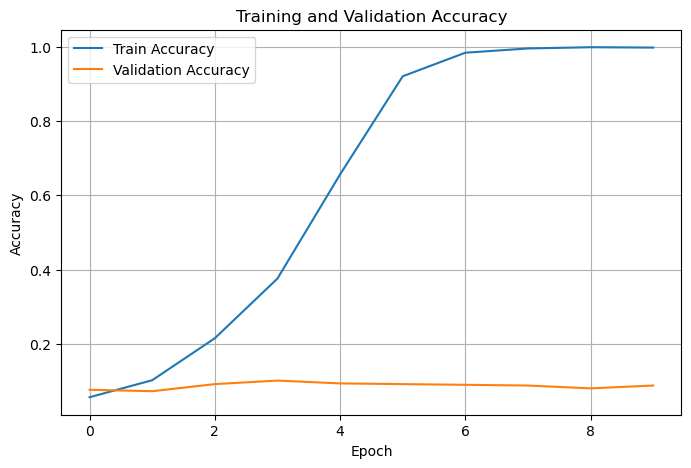

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(test_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

What can you say about overfitting? What can be done to improve the accuracy of the model

This is a clear sign of overfitting.
Train Accuracy: 0.9938 (almost perfect)
Test Accuracy: 0.0821 (very low, close to random guessing).
This model has learned to classify the training data extremely well, but it cannot generalize to new, unseen data (the test set).

## Optional: Calculate Top3 Accuracy

In this exercise, we were dealing with classification with quite high number of classes (35), so our result - around 50% validation accuracy - is pretty good. Standard ImageNet dataset has even more - 1000 classes.

In such cases it is difficult to ensure that model **always** correctly predicts the class. There are cases when two breeds are very similar to each other, and the model returns very similar probablities (eg., 0.45 and 0.43). If we measure standard accuracy, it will be considered a wrong case, even though the model did very small mistake. This, we often measure another metric - an accuracy within top 3 most probable predictions of the model.

We consider the case accurate if target label is contained within top 3 model predictions. 

To compute top-3 accuracy on the test dataset, you need to manually go over the dataset, apply the neural network to get the prediction, and then do the calculations. Some hints:

* In Tensorflow, use `tf.nn.in_top_k` function to see if the `predictions` (output of the model) are in top-k (pass `k=3` as parameter), with respect to `targets`. This function returns a tensor of boolean values, which can be converted to `int` using `tf.cast`, and then accumulated using `tf.reduce_sum`.
* In PyTorch, you can use `torch.topk` function to get indices of classes with highers probabilities, and then see if the correct class belongs to them. See [this](https://gist.github.com/weiaicunzai/2a5ae6eac6712c70bde0630f3e76b77b) for more hints.


In [15]:
import torch

model.eval()
top3_correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # Get top 3 predictions for each sample
        _, top3_pred = outputs.topk(3, dim=1)
        # Check if true label is in top 3 predictions
        top3_correct += sum([labels[i] in top3_pred[i] for i in range(labels.size(0))])
        total += labels.size(0)

top3_acc = top3_correct / total
print(f"Top-3 Accuracy on test set: {top3_acc:.4f}")

Top-3 Accuracy on test set: 0.2042


## Optional: Build Cats vs. Dogs classification

We also want to see how accurate our binary cats vs. dogs classification would be on the same dateset. To do it, we need to adjust labels:

In [22]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch
from torch.utils.data import Dataset


cat_breeds = [
    "Abyssinian", "Birman", "Bombay", "Egyptian", "Maine", "Persian", "Ragdoll",
    "Russian", "Scottish", "Siamese", "Sphynx", "British", "Bengal"
]
dog_breeds = [
    "american", "basset", "beagle", "boxer", "chihuahua", "english", "german", "great",
    "havanese", "japanese", "keeshond", "leonberger", "miniature", "newfoundland",
    "pomeranian", "pug", "saint", "samoyed", "shiba", "staffordshire", "wheaten", "yorkshire"
]

class BinaryPetDataset(Dataset):
    def __init__(self, imagefolder_dataset, cat_breeds, dog_breeds):
        self.samples = [
            (path, 0 if imagefolder_dataset.classes[class_idx] in cat_breeds else 1)
            for path, class_idx in imagefolder_dataset.samples
            if imagefolder_dataset.classes[class_idx] in cat_breeds + dog_breeds
        ]
        self.transform = imagefolder_dataset.transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        from PIL import Image
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def binary_target_transform(target):
    class_name = dataset.classes[target]
    if class_name in cat_breeds:
        return 0
    else:
        return 1
    
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

imagefolder_dataset = ImageFolder('images', transform=transform)
binary_dataset = BinaryPetDataset(imagefolder_dataset, cat_breeds, dog_breeds)


train_size = int(0.8 * len(binary_dataset))
test_size = len(binary_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(binary_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Epoch [1/10], Train Acc: 0.6535, Test Acc: 0.6790
Epoch [2/10], Train Acc: 0.6628, Test Acc: 0.6790
Epoch [3/10], Train Acc: 0.6750, Test Acc: 0.6887
Epoch [4/10], Train Acc: 0.7300, Test Acc: 0.7257
Epoch [5/10], Train Acc: 0.7900, Test Acc: 0.7412
Epoch [6/10], Train Acc: 0.8519, Test Acc: 0.7257
Epoch [7/10], Train Acc: 0.8947, Test Acc: 0.7160
Epoch [8/10], Train Acc: 0.9425, Test Acc: 0.7101
Epoch [9/10], Train Acc: 0.9751, Test Acc: 0.7315
Epoch [10/10], Train Acc: 0.9888, Test Acc: 0.6984


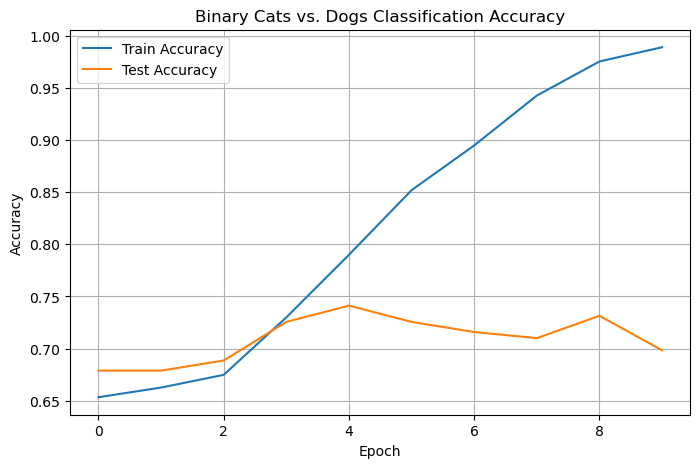

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple binary classifier CNN
class BinaryPetCNN(nn.Module):
    def __init__(self):
        super(BinaryPetCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: cat, dog

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BinaryPetCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = correct / total
    train_acc_history.append(train_acc)

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = correct / total
    test_acc_history.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Plot accuracy curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(test_acc_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Binary Cats vs. Dogs Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()